In [1]:
import numpy
import joblib
import mne.stats
import scipy.stats
import tqdm.contrib.itertools

def compute(edges: numpy.ndarray, features: numpy.ndarray, alpha: float = 0.01):
    def process_feature(st1, st2, feature_idx):
        x = features[edges[st1]:edges[st1 + 1], feature_idx]
        y = features[edges[st2]:edges[st2 + 1], feature_idx]
        return scipy.stats.mannwhitneyu(x, y)[1]

    n_stages = len(edges) - 1
    flat_result = joblib.Parallel(n_jobs = -1)(
        joblib.delayed(process_feature)(st1, st2, feature_idx)
        for st1, st2, feature_idx in tqdm.contrib.itertools.product(range(n_stages), range(n_stages), range(features.shape[1]))
    )
    _, flat_result = mne.stats.bonferroni_correction(flat_result, alpha=alpha)
    result = flat_result.reshape((n_stages, n_stages, features.shape[1]))
    return (result < alpha).mean(axis=2)

In [ ]:
import os
import tqdm
import numpy
import pandas
import seaborn
import matplotlib.pyplot as plt

EXPS = [
    # ("exp_full_flow", "traditional"),
    # ("exp_full_flow", "topological"),
    ("exp_full_flow", "best_topological"),
    # ("exp_shuffled", "traditional"),
    ("exp_shuffled", "best_topological"),
    # ("exp_noise", "best_topological")
]

plt.rcParams.update({'font.size': 28})

for subj in ["Subj1", "Subj2", "Subj3", *[f"phase2/Subj{i + 1}" for i in range(30)]]:
    print(subj)
    for exp, result in EXPS:
        if subj.startswith("phase2/") and exp == "exp_full_flow":
            exp = "exp_reduced_flow"
        edges = numpy.loadtxt(f"E:/CourseProject/{subj}/{exp}/results/{result}/best_edges.txt").astype(int)
        features = numpy.load(f"E:/CourseProject/{subj}/{exp}/results/{result}/all_features.npy")
        scores = compute(edges, features)

        dir = f"{subj}/exp_stat_test/{exp}/{result}"
        os.makedirs(dir, exist_ok = True)
        pandas.DataFrame(scores).to_csv(f"{dir}/scores.csv")

        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        seaborn.heatmap(
            (scores * 100).astype(int),
            vmin=0,
            vmax=1000,
            annot=True,
            cbar=False,
            fmt="d",
            cmap="YlGnBu",
            linewidths=0.5,
            linecolor='black',
            ax=ax
        )
        fig.tight_layout()
        fig.savefig(f"{dir}/scores.png")
        fig.savefig(f"{dir}/scores.svg")
        plt.close(fig)

In [7]:
import pandas

subj1 = pandas.read_csv("Subj1/exp_stat_test/exp_full_flow/best_topological/scores.csv").drop(columns=['Unnamed: 0'])
subj2 = pandas.read_csv("Subj2/exp_stat_test/exp_full_flow/best_topological/scores.csv").drop(columns=['Unnamed: 0'])
subj3 = pandas.read_csv("Subj3/exp_stat_test/exp_full_flow/best_topological/scores.csv").drop(columns=['Unnamed: 0'])

subj1

,0,1,2,3,4,5,6,7,8
0,0.000000,0.221818,0.250909,0.356364,0.598182,0.447879,0.263636,0.497576,0.338788
1,0.221818,0.000000,0.254545,0.359394,0.641212,0.144848,0.201212,0.643636,0.175152
2,0.250909,0.254545,0.000000,0.111515,0.496970,0.276970,0.084848,0.529091,0.126061
3,0.356364,0.359394,0.111515,0.000000,0.641212,0.263030,0.000000,0.578788,0.010909
4,0.598182,0.641212,0.496970,0.641212,0.000000,0.684848,0.477576,0.129091,0.591515
5,0.447879,0.144848,0.276970,0.263030,0.684848,0.000000,0.164848,0.685455,0.110909
6,0.263636,0.201212,0.084848,0.000000,0.477576,0.164848,0.000000,0.443030,0.004848
7,0.497576,0.643636,0.529091,0.578788,0.129091,0.685455,0.443030,0.000000,0.578788
8,0.338788,0.175152,0.126061,0.010909,0.591515,0.110909,0.004848,0.578788,0.000000


(0.26715334313377354, 0.2592917600242286)

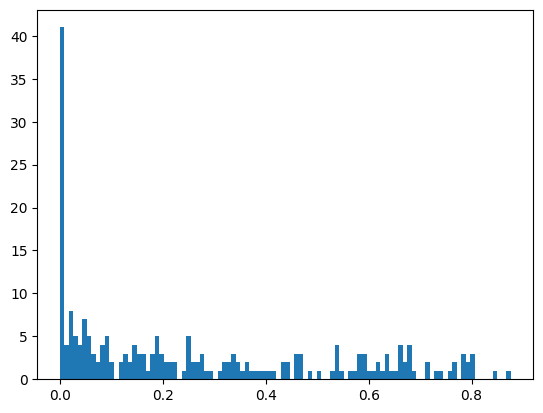

In [28]:
res = []
for i in range(1, 31):
    t = pandas.read_csv(f"phase2/Subj{i}/exp_stat_test/exp_reduced_flow/best_topological/scores.csv").drop(columns=['Unnamed: 0'])
    res.extend(t.to_numpy().flatten()[1::len(t) + 1])
res = numpy.array(res)
plt.hist(res, bins=100)
res.mean(), res.std()

(array([2., 1., 1., 0., 0., 1., 0., 0., 1., 2.]),
 array([0.11151515, 0.16884848, 0.22618182, 0.28351515, 0.34084848,
        0.39818182, 0.45551515, 0.51284848, 0.57018182, 0.62751515,
        0.68484848]),
 <BarContainer object of 10 artists>)

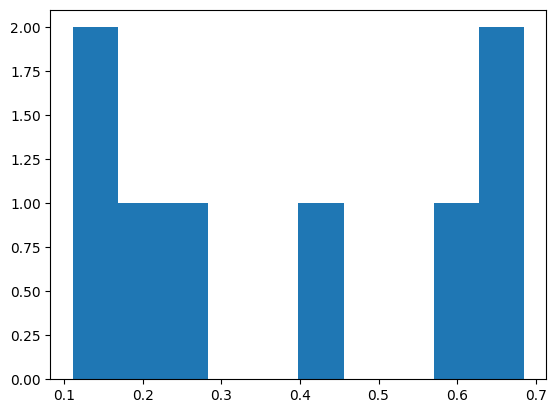

In [13]:
import matplotlib.pyplot as plt

plt.hist(subj1.to_numpy().flatten()[1::len(subj1) + 1])

(array([3., 3., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.02242424, 0.08690909, 0.15139394, 0.21587879, 0.28036364,
        0.34484848, 0.40933333, 0.47381818, 0.53830303, 0.60278788,
        0.66727273]),
 <BarContainer object of 10 artists>)

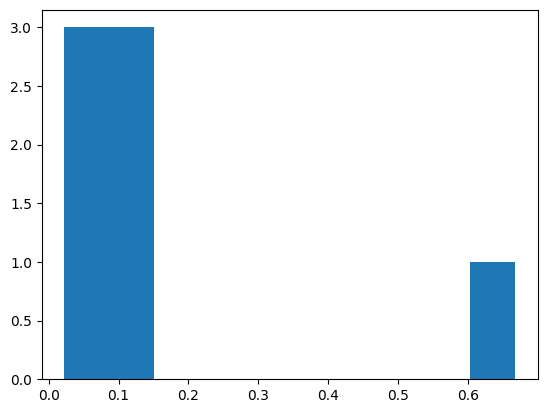

In [14]:
plt.hist(subj2.to_numpy().flatten()[1::len(subj2) + 1])

(array([3., 3., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.02242424, 0.08690909, 0.15139394, 0.21587879, 0.28036364,
        0.34484848, 0.40933333, 0.47381818, 0.53830303, 0.60278788,
        0.66727273]),
 <BarContainer object of 10 artists>)

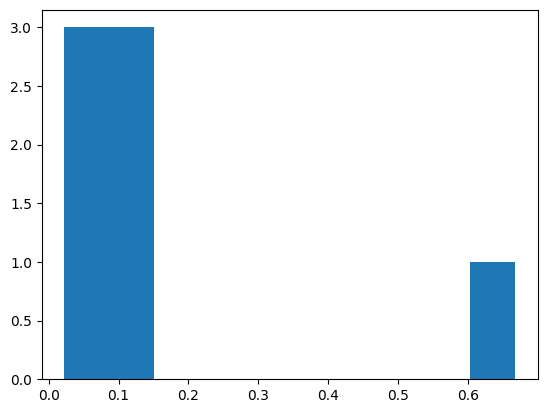

In [15]:
plt.hist(subj2.to_numpy().flatten()[1::len(subj2) + 1])